# Supplementary Figure — Subclonal mutation signatures

Subclonal signature composition and SBS3 / SBS1 ratios across bulk WGS cohorts
(PCAWG, SCAN-B, INFORM, GEL) and single-cell scNanoSeq tumour samples.

The notebook is fully self-contained: every panel is produced from two supplementary tables.

| Panel | Source table |
|-------|--------------|
| A. Clonal vs subclonal burden — PCAWG / SCAN-B / INFORM | Sup. Table 8, sheet `A.internal_composition` |
| B. Clonal vs subclonal burden + subclonal signature composition — GEL | Sup. Table 8, sheet `B.GEL_composition_sigs` |
| C. Late-clonal vs subclonal SBS3 / SBS1 — GEL | Sup. Table 8, sheet `C.GEL_late_vs_subclonal` |
| D. Clonal / subclonal / private SBS3 / SBS1 — scNanoSeq | Sup. Table 9, sheet `A.ratios` |
| E. Per-cell mutation counts by cellular evidence — scNanoSeq | Sup. Table 9, sheet `B.perCell_category_counts` |

In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import spearmanr

mpl.rcParams.update({
    "pdf.fonttype": 42, "ps.fonttype": 42,
    "font.family": "sans-serif", "font.size": 11,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.linewidth": 0.5,
    "xtick.major.width": 0.5, "ytick.major.width": 0.5,
    "figure.dpi": 150,
})

TABLES = Path("../supplemental_tables_v2")
OUT    = Path("../output/SuppFig_subclonal_signatures"); OUT.mkdir(parents=True, exist_ok=True)

T8 = TABLES / "SupTable6_subclonal_bulk.xlsx"
T9 = TABLES / "SupTable7_scNanoSeq_subclonal.xlsx"

CLONAL_C, SUBCLONAL_C = "#4c72b0", "#dd8452"


## A. Clonal vs subclonal mutation burden — PCAWG / SCAN-B / INFORM

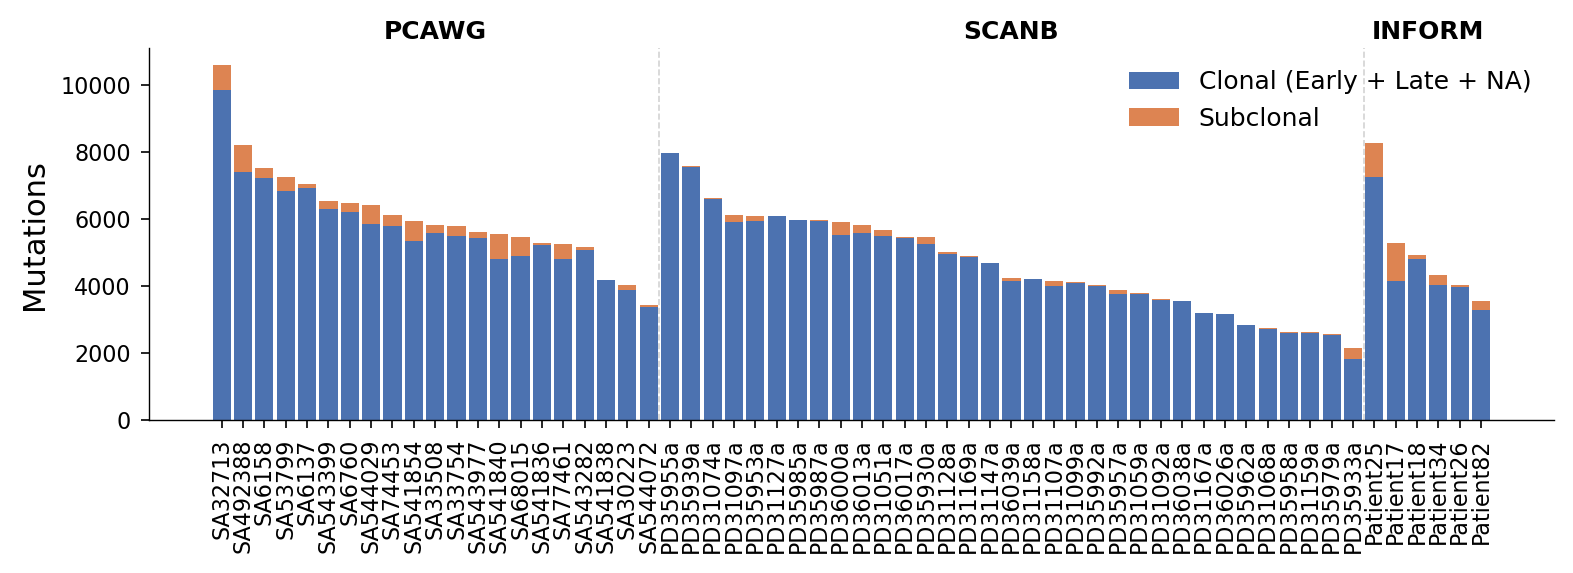

Overall subclonal fraction (pooled): 0.040
        pooled_frac  mean_per_patient  n_patients
cohort                                           
PCAWG         0.057             0.054        21.0
SCANB         0.015             0.017        33.0
INFORM        0.096             0.088         6.0


In [2]:
comp = pd.read_excel(T8, sheet_name="A.internal_composition")
comp["cohort"] = pd.Categorical(comp["cohort"], ["PCAWG", "SCANB", "INFORM"], ordered=True)
comp = comp.sort_values(["cohort", "n_total"], ascending=[True, False]).reset_index(drop=True)

labels  = comp["sample_display"].astype(str).tolist()
cohorts = comp["cohort"].astype(str).to_numpy()
x = np.arange(len(comp))

fig, ax = plt.subplots(figsize=(8, 3), dpi=200)
ax.bar(x, comp["Clonal"],    color=CLONAL_C,    width=0.85, label="Clonal (Early + Late + NA)")
ax.bar(x, comp["Subclonal"], bottom=comp["Clonal"], color=SUBCLONAL_C, width=0.85, label="Subclonal")
ax.set_ylabel("Mutations")
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=90, fontsize=6)
ax.legend(frameon=False, fontsize=9, loc="upper right")
ax.tick_params(labelsize=8, direction="out", length=3, width=0.6)

for c in np.where(cohorts[:-1] != cohorts[1:])[0]:
    ax.axvline(c + 0.5, color="lightgrey", lw=0.6, ls="--", zorder=0)
ymax = ax.get_ylim()[1]
for coh in pd.unique(cohorts):
    idx = np.where(cohorts == coh)[0]
    ax.text((idx[0] + idx[-1]) / 2, ymax * 1.01, coh, ha="center", va="bottom",
            fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig(OUT / "SUPP_clonal_vs_subclonal_PCAWG_SCANB_INFORM.pdf", bbox_inches="tight")
plt.show()

tot = comp["Clonal"] + comp["Subclonal"]
per = comp.groupby("cohort", observed=True).apply(
    lambda g: pd.Series({
        "pooled_frac":      g["Subclonal"].sum() / (g["Clonal"].sum() + g["Subclonal"].sum()),
        "mean_per_patient": (g["Subclonal"] / (g["Clonal"] + g["Subclonal"])).mean(),
        "n_patients":       len(g)}), include_groups=False).round(3)
print(f"Overall subclonal fraction (pooled): {comp['Subclonal'].sum() / tot.sum():.3f}")
print(per)

## B. Clonal vs subclonal burden and subclonal signature composition — GEL

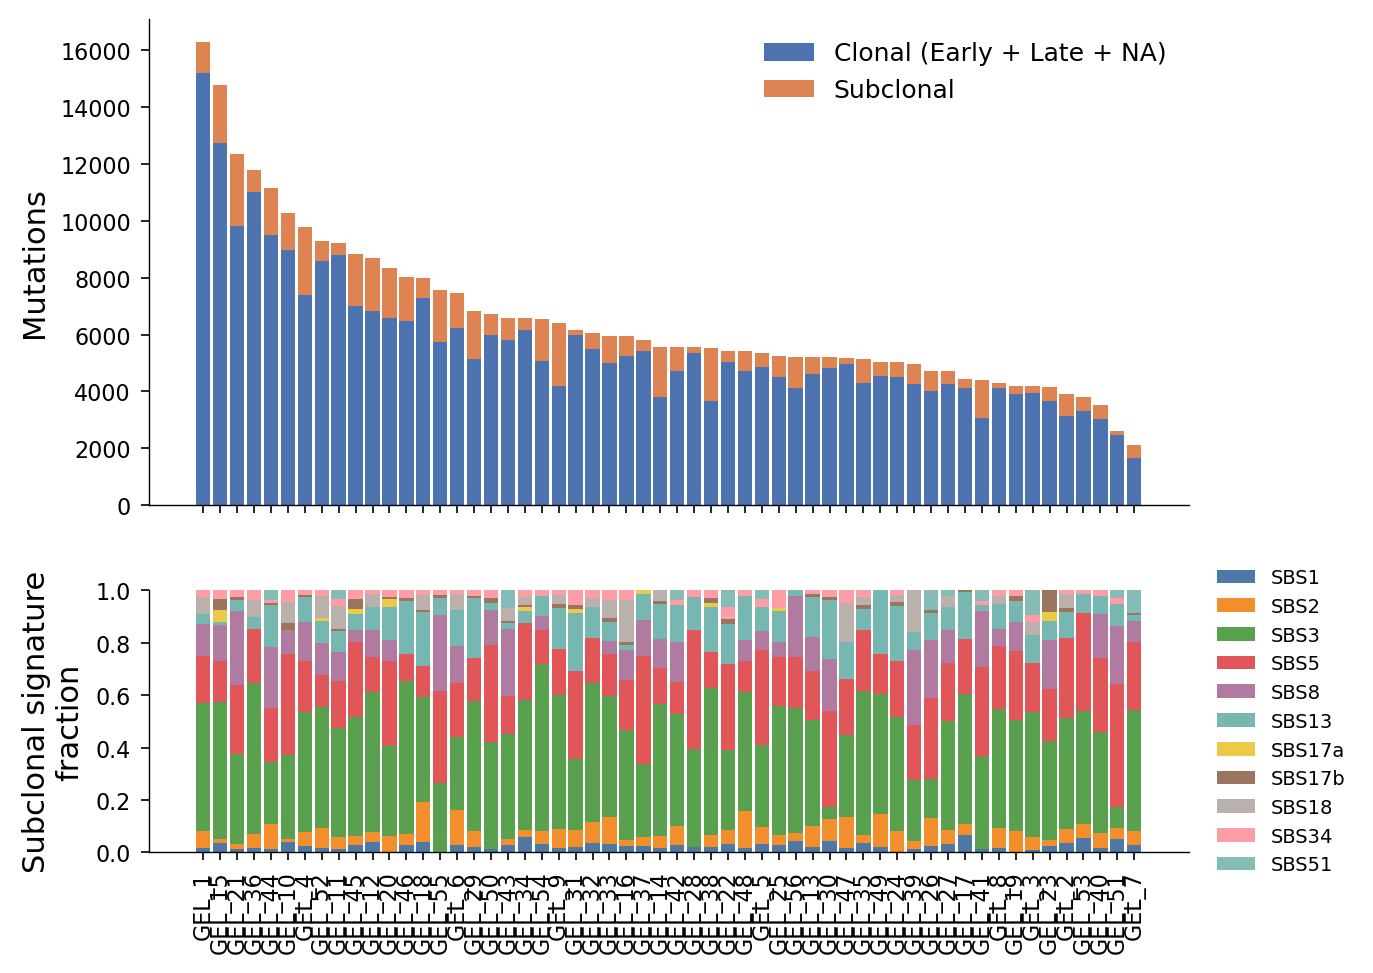

GEL  n = 56
GEL  overall subclonal fraction (pooled): 0.142
GEL  mean per-sample subclonal fraction:  0.141


In [3]:
summary = pd.read_excel(T8, sheet_name="B.GEL_composition_sigs")
summary = summary.sort_values("n_total", ascending=False).reset_index(drop=True)
order = summary["sample_id"].tolist()

sub_exp = summary.filter(like="sub_exp_").copy()
sub_exp.columns = [c.replace("sub_exp_", "") for c in sub_exp.columns]
sub_frac = sub_exp.div(sub_exp.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)
sub_frac = sub_frac[sub_frac.columns[sub_frac.sum(axis=0) > 0]]

palette = ["#4E79A7", "#F28E2B", "#59A14F", "#E15759", "#B07AA1", "#76B7B2",
           "#EDC948", "#9C755F", "#BAB0AC", "#FF9DA7", "#86BCB6", "#D4A6C8"]
colors = [palette[i % len(palette)] for i in range(len(sub_frac.columns))]

fig, axes = plt.subplots(2, 1, figsize=(7, 5), dpi=200, sharex=True,
                         gridspec_kw={"height_ratios": [0.65, 0.35]})
x = np.arange(len(order))

ax = axes[0]
ax.bar(x, summary["n_clonal"], color=CLONAL_C, width=0.85, label="Clonal (Early + Late + NA)")
ax.bar(x, summary["n_subclonal"], bottom=summary["n_clonal"], color=SUBCLONAL_C, width=0.85, label="Subclonal")
ax.set_ylabel("Mutations")
ax.legend(frameon=False, fontsize=9, loc="upper right")
ax.tick_params(labelsize=8, direction="out", length=3, width=0.6)

ax = axes[1]
bottom = np.zeros(len(order))
for sig, col in zip(sub_frac.columns, colors):
    ax.bar(x, sub_frac[sig], bottom=bottom, color=col, width=0.85, lw=0, label=sig)
    bottom += sub_frac[sig].values
ax.set_ylabel("Subclonal signature\nfraction"); ax.set_ylim(0, 1)
ax.set_xticks(x); ax.set_xticklabels(order, rotation=90, fontsize=6)
ax.legend(frameon=False, fontsize=7, loc="center left", bbox_to_anchor=(1.01, 0.5))
ax.tick_params(labelsize=8, direction="out", length=3, width=0.6)

plt.tight_layout()
plt.savefig(OUT / "SUPP_GEL_clonal_vs_subclonal_and_sigcomp.pdf", bbox_inches="tight")
plt.show()

tot = summary["n_clonal"] + summary["n_subclonal"]
print(f"GEL  n = {len(summary)}")
print(f"GEL  overall subclonal fraction (pooled): {summary['n_subclonal'].sum() / tot.sum():.3f}")
print(f"GEL  mean per-sample subclonal fraction:  {(summary['n_subclonal'] / tot).mean():.3f}")

## C. Late-clonal vs subclonal SBS3 / SBS1 — GEL

Per sample, the SBS3 / SBS1 ratio in **late-clonal** vs **subclonal** mutations with 95%
bootstrap CIs. Points on the diagonal have an unchanged ratio between the two timing classes.
Samples require median SBS1 **and** SBS3 counts ≥ 10 in both classes.

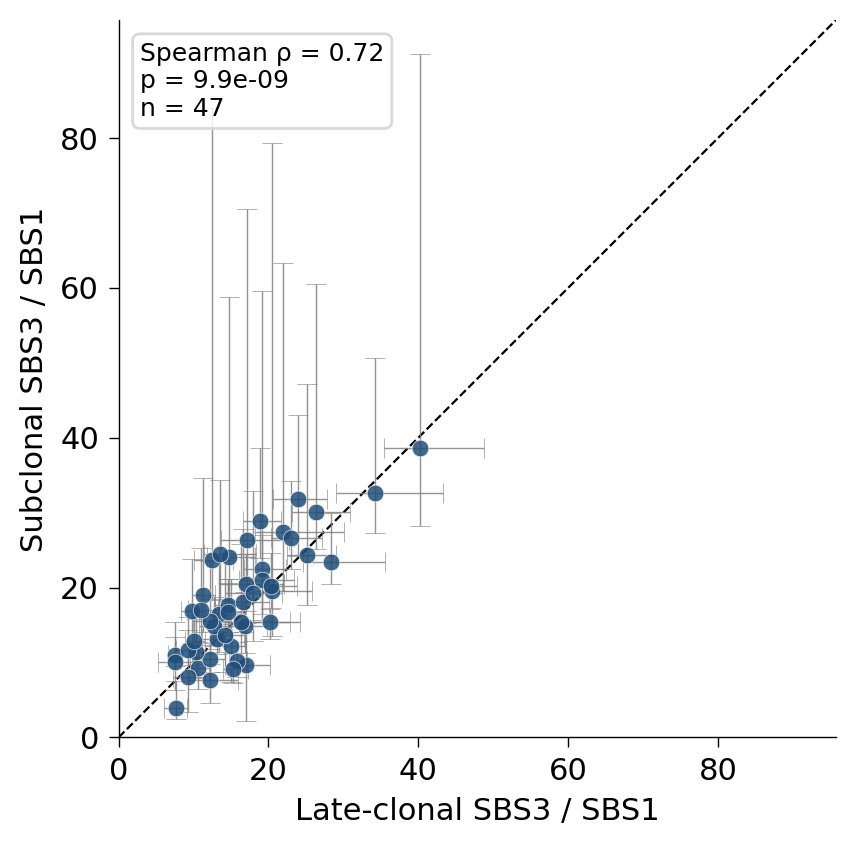

In [4]:
MIN_MEDIAN = 10
s = pd.read_excel(T8, sheet_name="C.GEL_late_vs_subclonal")
s = s[(s["late_SBS1_med"] >= MIN_MEDIAN) & (s["late_SBS3_med"] >= MIN_MEDIAN) &
      (s["sub_SBS1_med"]  >= MIN_MEDIAN) & (s["sub_SBS3_med"]  >= MIN_MEDIAN)].copy()

rho, p = spearmanr(s["late_med"], s["sub_med"])
pstr = "p < 1e-300" if p == 0 else (f"p = {p:.1e}" if p < 1e-4 else f"p = {p:.3f}")

xerr = [s["late_med"] - s["late_lo95"], s["late_hi95"] - s["late_med"]]
yerr = [s["sub_med"]  - s["sub_lo95"],  s["sub_hi95"]  - s["sub_med"]]

fig, ax = plt.subplots(figsize=(4.4, 4.4), dpi=200)
ax.errorbar(s["late_med"], s["sub_med"], xerr=xerr, yerr=yerr,
            fmt="o", markersize=6, markerfacecolor="#1f4e79", markeredgecolor="white",
            markeredgewidth=0.25, ecolor="grey", elinewidth=0.5, capsize=3.5,
            capthick=0.5, alpha=0.85, zorder=3)
lim = [0, max(s["late_hi95"].max(), s["sub_hi95"].max()) * 1.05]
ax.plot(lim, lim, "k--", lw=0.8, zorder=2)
ax.set_xlim(lim); ax.set_ylim(lim); ax.set_aspect("equal")
ax.set_xlabel("Late-clonal SBS3 / SBS1"); ax.set_ylabel("Subclonal SBS3 / SBS1")
ax.annotate(f"Spearman ρ = {rho:.2f}\n{pstr}\nn = {len(s)}",
            xy=(0.03, 0.97), xycoords="axes fraction", ha="left", va="top", fontsize=9,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="lightgray", alpha=0.85))
plt.tight_layout()
plt.savefig(OUT / "SUPP_late_vs_sub_SBS3_SBS1_GEL.pdf", bbox_inches="tight")
plt.show()

## D. Clonal / subclonal / private SBS3 / SBS1 — scNanoSeq

Per single-cell-derived tumour sample, SBS3 / SBS1 ratios from mutations grouped by cellular
evidence: **Clonal** (> 10 cells), **subclonal** (2–10 cells) and **private** (1 cell),
with 95% bootstrap CIs.

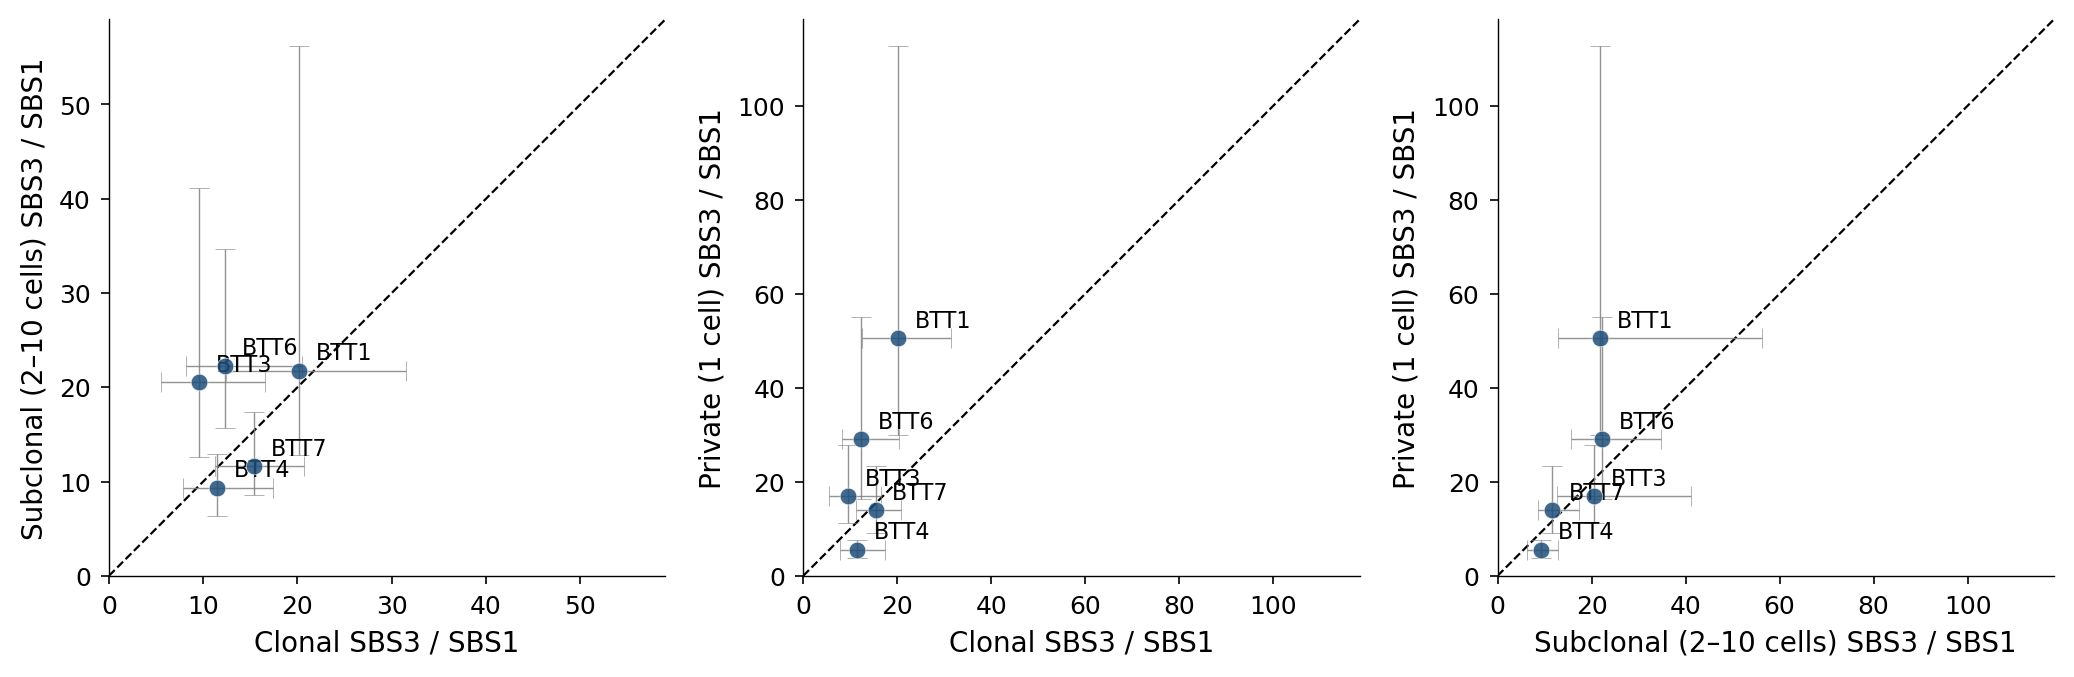

,Sample,Clonal_R,Clonal_L,Clonal_H,Other_R,Other_L,Other_H,Private_R,Private_L,Private_H
0,BTT1,20.176229,7.707243,11.329100,21.758801,8.980793,34.456456,50.500621,20.582502,62.237061
1,BTT4,11.437104,3.534828,5.936041,9.334819,3.016623,3.607253,5.592943,1.721874,2.088201
2,BTT7,15.388517,4.135778,5.309127,11.625309,3.084998,5.725716,13.936307,4.785523,9.475182
3,BTT3,9.579948,4.017497,6.934687,20.548862,7.947050,20.616187,16.938014,5.676073,10.996244
4,BTT6,12.346549,4.134042,8.113190,22.293894,6.663021,12.386314,29.102152,12.729673,25.892150


In [5]:
df = pd.read_excel(T9, sheet_name="A.ratios")

err_kwargs = dict(fmt="o", markersize=6, markerfacecolor="#1f4e79", markeredgecolor="white",
                  markeredgewidth=0.25, ecolor="grey", elinewidth=0.5, capsize=3.5,
                  capthick=0.5, alpha=0.85, zorder=3)

def scatter(ax, xc, yc, xe, ye, xlab, ylab):
    xv, yv = df[xc], df[yc]
    xerr = [df[xe[0]], df[xe[1]]]; yerr = [df[ye[0]], df[ye[1]]]
    ax.errorbar(xv, yv, xerr=xerr, yerr=yerr, **err_kwargs)
    hi = max((xv + xerr[1]).max(), (yv + yerr[1]).max()) * 1.05
    ax.plot([0, hi], [0, hi], "k--", lw=0.8, zorder=2)
    ax.set_xlim(0, hi); ax.set_ylim(0, hi); ax.set_aspect("equal")
    for i, t in enumerate(df["Sample"]):
        ax.annotate(t, (xv.iloc[i], yv.iloc[i]), xytext=(6, 4),
                    textcoords="offset points", fontsize=8)
    ax.set_xlabel(xlab, fontsize=10); ax.set_ylabel(ylab, fontsize=10)
    ax.tick_params(labelsize=9, direction="out", length=3, width=0.6)

fig, axes = plt.subplots(1, 3, figsize=(10.5, 4.0), dpi=200)
scatter(axes[0], "Clonal_R", "Other_R", ["Clonal_L", "Clonal_H"], ["Other_L", "Other_H"],
        "Clonal SBS3 / SBS1", "Subclonal (2–10 cells) SBS3 / SBS1")
scatter(axes[1], "Clonal_R", "Private_R", ["Clonal_L", "Clonal_H"], ["Private_L", "Private_H"],
        "Clonal SBS3 / SBS1", "Private (1 cell) SBS3 / SBS1")
scatter(axes[2], "Other_R", "Private_R", ["Other_L", "Other_H"], ["Private_L", "Private_H"],
        "Subclonal (2–10 cells) SBS3 / SBS1", "Private (1 cell) SBS3 / SBS1")
plt.tight_layout()
plt.savefig(OUT / "SUPP_scNanoSeq_clonal_subclonal_private_SBS3_SBS1.pdf", bbox_inches="tight")
plt.show()
df

## E. Per-cell mutation counts by cellular evidence — scNanoSeq

For each tumour sample, the number of detected somatic mutations per cell, coloured by the
cellular-evidence category of each mutation (private, subclonal, clonal, or low-coverage).
Cells are ordered by total mutation count.

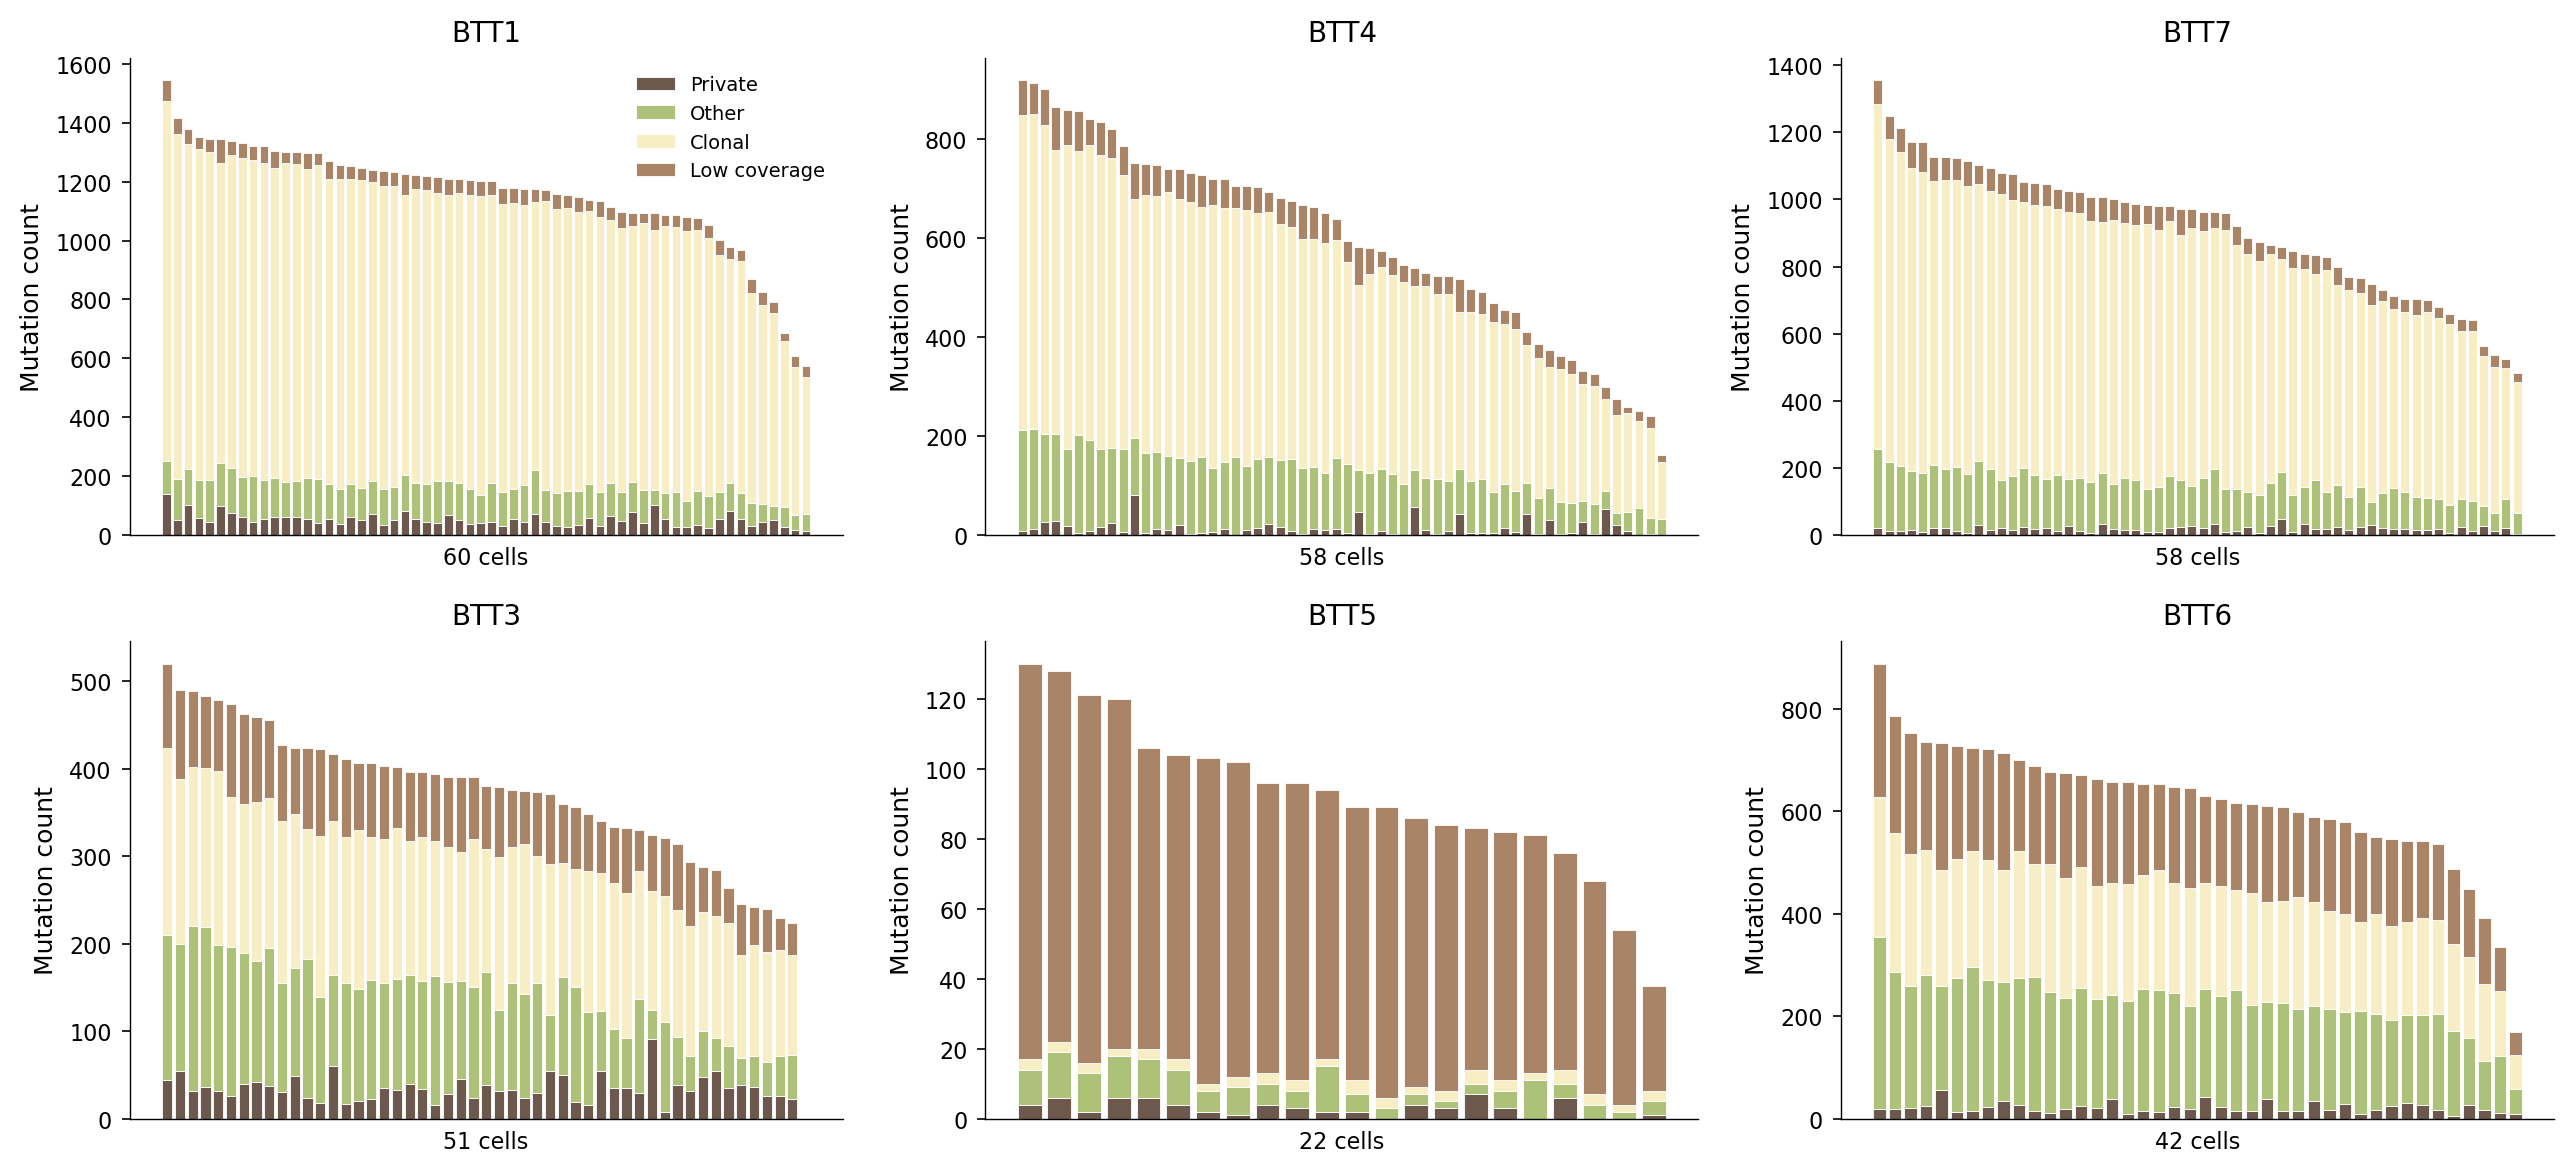

In [6]:
bars = pd.read_excel(T9, sheet_name="B.perCell_category_counts")
cats   = ["Private", "Other", "Clonal", "Low coverage"]
colors = ["#6c584c", "#adc178", "#f8eec6", "#a98467"]
samples = ["BTT1", "BTT4", "BTT7", "BTT3", "BTT5", "BTT6"]

fig, axes = plt.subplots(2, 3, figsize=(13, 6), dpi=200)
for ax, sm in zip(axes.ravel(), samples):
    d = bars[bars["Sample"] == sm].sort_values("Total", ascending=False).reset_index(drop=True)
    xi = np.arange(len(d)); bottom = np.zeros(len(d))
    for c, col in zip(cats, colors):
        ax.bar(xi, d[c], bottom=bottom, color=col, edgecolor="white", linewidth=0.3,
               label=c if sm == samples[0] else None)
        bottom += d[c].values
    ax.set_title(sm, fontsize=10)
    ax.set_ylabel("Mutation count", fontsize=9)
    ax.set_xticks([]); ax.set_xlabel(f"{len(d)} cells", fontsize=8)
    ax.tick_params(labelsize=8, length=3, width=0.6)
axes.ravel()[0].legend(fontsize=7, frameon=False, loc="upper right")
plt.tight_layout()
plt.savefig(OUT / "SUPP_scNanoSeq_perCell_mutation_counts.pdf", bbox_inches="tight")
plt.show()